In [32]:
import os
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.offsetbox import (
    OffsetImage,
    AnnotationBbox
)

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

In [3]:
from tensorflow.keras.applications import ResNet50

from tensorflow.keras.applications.resnet50 import(
    preprocess_input
)

from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D

In [4]:
features = np.load(
    "shoe_image_embeddings.npy"
)

filenames = np.load(
    "shoe_image_filenames.npy",
    allow_pickle=True
)

print(features.shape)
print(len(filenames))

(2000, 2048)
2000


In [5]:
dataset_path = r"sampled_sneakers_1024x1024"

In [6]:
base_model=ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

In [7]:
x=GlobalAveragePooling2D()(
    base_model.output
)

feature_extractor=Model(
    inputs=base_model.input,
    outputs=x
)

In [10]:
def preprocess_image(img_path):

    img=image.load_img(
        img_path,
        target_size=(224, 224)                #ResNet expects 224x224 image.
    )

    img_array=image.img_to_array(img)

    img_array=np.expand_dims(               #converts (a, b, c) shape -> (1, a, b, c), batches are expected in tensorflow even if size of 1.
        img_array,
        axis=0
    )

    img_array=preprocess_input(
        img_array
    )

    return img_array

In [11]:
def get_embedding(img_path):

    processed_img=preprocess_image(
        img_path
    )

    embedding=feature_extractor.predict(
        processed_img,
        verbose=0
    )

    return embedding.flatten()

In [16]:
def retrieve_similar_images(query_image_path, top_k=5):
    query_embedding=get_embedding(
        query_image_path
    )

    similarities=cosine_similarity(
        [query_embedding],
        features
    )[0]

    top_indices=np.argsort(
        similarities
    )[::-1][:top_k]

    similar_images=[]

    for idx in top_indices:
        similar_images.append(
            (filenames[idx], similarities[idx])
        )

    return similar_images

In [14]:
def show_results(query_image_path, results):
    plt.figure(figsize=(15, 5))                           #figure->page, subplot->divides page into sections, imshow->puts image in one section.

    #query image
    plt.subplot(1, len(results)+1, 1)

    query_img=image.load_img(
        query_image_path,
        target_size=(224, 224)
    )

    plt.imshow(query_img)
    plt.title("Query")
    plt.axis("off")

    #retrieved image
    for i, (filename, score) in enumerate(results):
        img_path=os.path.join(
            dataset_path,
            filename
        )

        img=image.load_img(
            img_path,
            target_size=(224, 224)
        )

        plt.subplot(1, len(results)+1, i+2)

        plt.imshow(img)

        plt.title(f"{score:.2f}")

        plt.axis("off")

    plt.show()

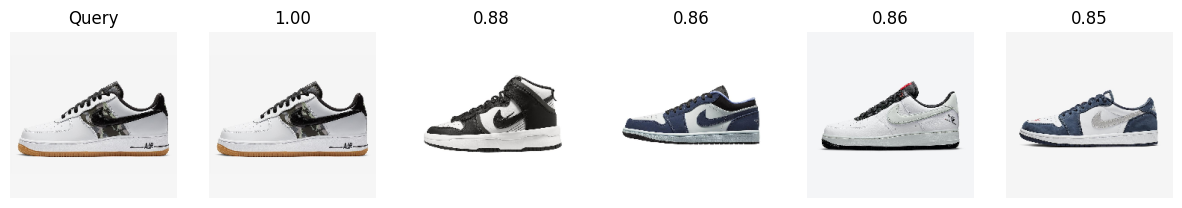

In [18]:
#test
query_image=os.path.join(
    dataset_path,
    filenames[100]
)

results=retrieve_similar_images(query_image, top_k=5)

show_results(query_image, results)

In [29]:
tsne=TSNE(
    n_components=2,
    perplexity=30,          #controls number of clusters.
    random_state=42,
    init='random',
    learning_rate='auto'
)

In [33]:
embeddings_2d=tsne.fit_transform(
    features
)

In [36]:
num_clusters = 8

kmeans = KMeans(

    n_clusters=num_clusters,

    random_state=42
)

cluster_labels = kmeans.fit_predict(
    features                                      #here we used tsne+kmeans, use performed kmeans on the actual 2048 dim vector 
                                                  #that forms the clusters and used tsne just to visualize them 2d.
)

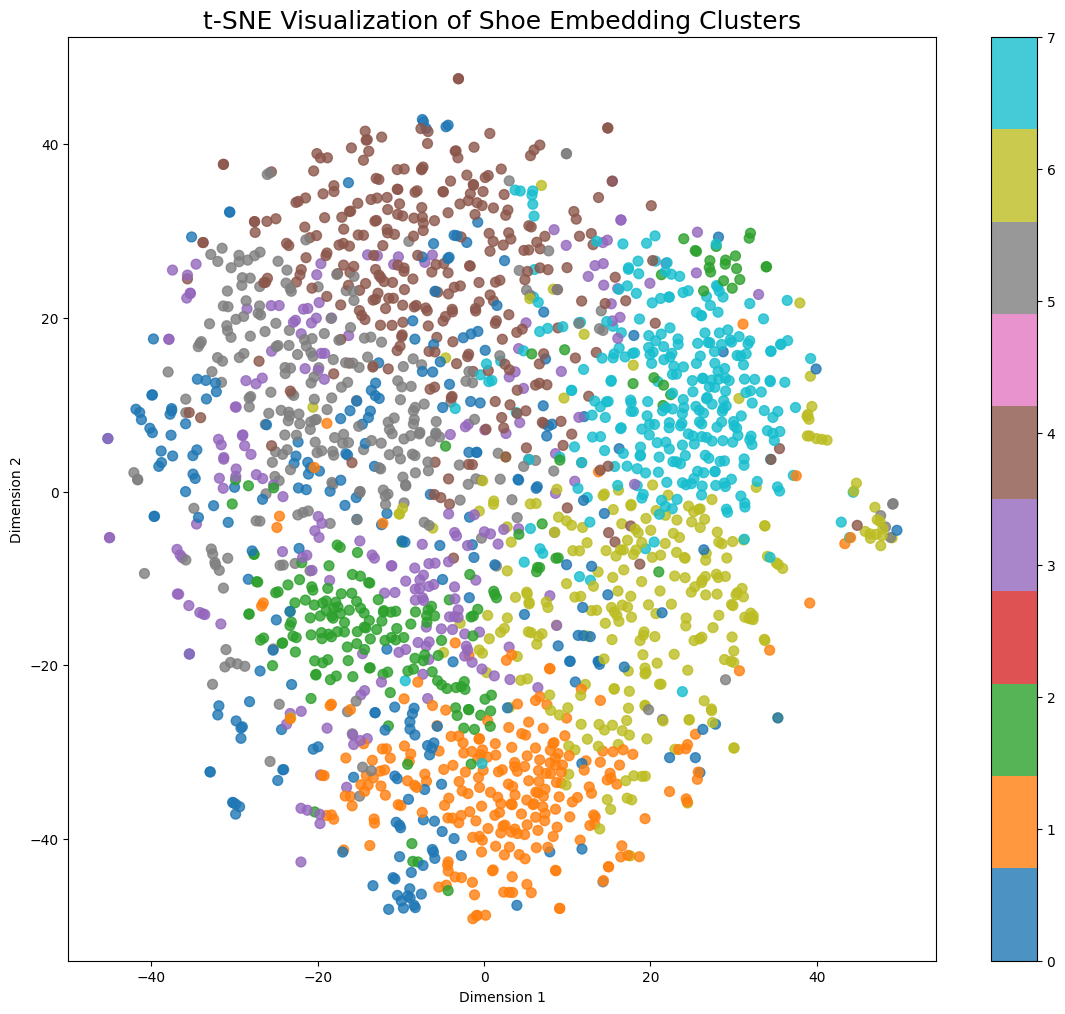

In [37]:
plt.figure(figsize=(14, 12))

scatter = plt.scatter(

    embeddings_2d[:, 0],
    embeddings_2d[:, 1],

    c=cluster_labels,

    cmap='tab10',

    alpha=0.8,

    s=50
)

plt.title(
    "t-SNE Visualization of Shoe Embedding Clusters",
    fontsize=18
)

plt.xlabel("Dimension 1")

plt.ylabel("Dimension 2")

plt.colorbar(scatter)

plt.show()